### [Portfolio Optimization: Mean-Variance vs Risk Parity vs Min-Vol](https://pub.towardsai.net/portfolio-optimization-with-python-mean-variance-vs-risk-parity-vs-min-vol-28fee8192d2f)

#### **Mean-Variance (Max Sharpe)**
This method tries to pick weights that give the best trade-off between expected return and risk.

#### **Min-Vol**
This method ignores expected returns and focuses only on reducing volatility.

#### **Risk Parity**
This method tries to spread risk evenly across assets, not money.

In [1]:
import numpy as np
import pandas as pd
import math

import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(10)

dates = pd.bdate_range("2023-01-02", "2025-12-31")
assets = ["US_Equity", "EU_Equity", "EM_Equity", "US_Bonds", "Gold", "Oil"]

corr = np.array([
    [1.00, 0.75, 0.65, -0.20, 0.10, 0.35],
    [0.75, 1.00, 0.60, -0.15, 0.12, 0.30],
    [0.65, 0.60, 1.00, -0.10, 0.08, 0.25],
    [-0.20,-0.15,-0.10,  1.00, 0.05,-0.05],
    [0.10, 0.12, 0.08,  0.05, 1.00, 0.15],
    [0.35, 0.30, 0.25, -0.05, 0.15, 1.00],
])

vol_calm = np.array([0.012, 0.011, 0.015, 0.004, 0.008, 0.018])
vol_stress = np.array([0.018, 0.016, 0.022, 0.006, 0.011, 0.028])

mu_calm  = np.array([0.00035, 0.00028, 0.00040, 0.00014, 0.00018, 0.00022])
mu_stress = np.array([0.00020, 0.00012, 0.00015, 0.00020, 0.00025, 0.00010])

def cov_from(vol):
    D = np.diag(vol)
    return D @ corr @ D

cov1 = cov_from(vol_calm)
cov2 = cov_from(vol_stress)

n = len(dates)
split = int(n * 2 / 3)

ret = np.zeros((n, len(assets)))
ret[:split]  = np.random.multivariate_normal(mu_calm, cov1, size=split)
ret[split:]  = np.random.multivariate_normal(mu_stress, cov2, size=n - split)

returns = pd.DataFrame(ret, index=dates, columns=assets)

display(returns.head().round(4))

train = returns.iloc[:split]
ann_mean = (train.mean() * 252).round(3)
ann_vol  = (train.std() * math.sqrt(252)).round(3)
summary = pd.DataFrame({"AnnMean": ann_mean, "AnnVol": ann_vol})

display(summary)

,US_Equity,EU_Equity,EM_Equity,US_Bonds,Gold,Oil
2023-01-02,-0.0179,-0.0124,-0.0002,0.0045,-0.0043,-0.0248
2023-01-03,-0.0038,0.0004,-0.0017,-0.0043,-0.0016,-0.0045
2023-01-04,0.0189,0.0086,0.0180,-0.0017,0.0051,0.0003
2023-01-05,-0.0270,-0.0235,-0.0140,-0.0076,-0.0168,-0.0043
2023-01-06,-0.0036,-0.0033,0.0006,-0.0016,0.0088,-0.0356


,AnnMean,AnnVol
US_Equity,0.218,0.191
EU_Equity,0.100,0.173
EM_Equity,0.235,0.237
US_Bonds,0.056,0.062
Gold,-0.072,0.125
Oil,-0.047,0.272


In [3]:
from scipy.optimize import minimize

def shrink_cov(S, shrink=0.25):
    D = np.diag(np.diag(S))
    return (1 - shrink) * S + shrink * D

def annualize(mu_daily, cov_daily, periods=252):
    return mu_daily * periods, cov_daily * periods

def min_vol_weights(mu_ann, cov_ann, bounds):
    n = cov_ann.shape[0]
    x0 = np.ones(n) / n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bnds = [bounds] * n
    obj = lambda w: w @ cov_ann @ w
    return minimize(obj, x0, bounds=bnds, constraints=cons).x

def max_sharpe_weights(mu_ann, cov_ann, bounds):
    n = len(mu_ann)
    x0 = np.ones(n) / n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bnds = [bounds] * n

    def neg_sharpe(w):
        ret = w @ mu_ann
        vol = math.sqrt(max(w @ cov_ann @ w, 1e-12))
        return -(ret / vol)

    return minimize(neg_sharpe, x0, bounds=bnds, constraints=cons).x

def risk_contributions(w, cov_ann):
    port_var = w @ cov_ann @ w
    m = cov_ann @ w
    contrib = w * m
    return contrib / port_var

def risk_parity_weights(mu_ann, cov_ann, bounds):
    n = cov_ann.shape[0]
    target = np.ones(n) / n
    x0 = np.ones(n) / n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bnds = [bounds] * n

    def obj(w):
        rc = risk_contributions(w, cov_ann)
        return np.sum((rc - target) ** 2)

    return minimize(obj, x0, bounds=bnds, constraints=cons).x

In [4]:
# --- One interface for all methods ---
METHODS = {
    "MeanVariance": max_sharpe_weights,
    "MinVol": min_vol_weights,
    "RiskParity": risk_parity_weights,
}

# Fit once on the first ~2 years (to show example weights)
train = returns.iloc[:split]
mu_hat = train.mean().values
cov_hat = shrink_cov(train.cov().values, shrink=0.25)
mu_ann, cov_ann = annualize(mu_hat, cov_hat)

bounds = (0, 0.6)

W = {}
for name, fn in METHODS.items():
    W[name] = fn(mu_ann, cov_ann, bounds=bounds)

weights = pd.DataFrame(W, index=assets).round(3)
display(weights)

rc = pd.DataFrame({"RiskParity_RC%": risk_contributions(W["RiskParity"], cov_ann)}, index=assets).round(3)
display(rc)

,MeanVariance,MinVol,RiskParity
US_Equity,0.278,0.073,0.092
EU_Equity,0.000,0.081,0.100
EM_Equity,0.122,0.014,0.076
US_Bonds,0.600,0.600,0.481
Gold,0.000,0.210,0.177
Oil,0.000,0.021,0.074


,RiskParity_RC%
US_Equity,0.167
EU_Equity,0.167
EM_Equity,0.167
US_Bonds,0.167
Gold,0.167
Oil,0.167


In [5]:
def backtest_shared(returns, methods, lookback=252, rebalance_days=21, shrink=0.25, bounds=(0, 0.6)):
    idx = returns.index
    n_assets = returns.shape[1]

    port = {name: pd.Series(index=idx, dtype=float) for name in ["EqualWeight"] + list(methods.keys())}

    for t in range(lookback, len(idx), rebalance_days):
        start = t
        end = min(t + rebalance_days, len(idx))

        window = returns.iloc[t - lookback : t]
        mu = window.mean().values
        cov = shrink_cov(window.cov().values, shrink=shrink)
        mu_ann, cov_ann = annualize(mu, cov)

        # Equal weight baseline
        w_eq = np.ones(n_assets) / n_assets

        # Methods (same interface)
        Wt = {name: fn(mu_ann, cov_ann, bounds=bounds) for name, fn in methods.items()}

        seg = returns.iloc[start:end].values
        port["EqualWeight"].iloc[start:end] = seg @ w_eq
        for name in methods.keys():
            port[name].iloc[start:end] = seg @ Wt[name]

    return pd.DataFrame(port).dropna()

def perf_stats(r, periods=252):
    cum = (1 + r).cumprod()
    years = len(r) / periods
    cagr = cum.iloc[-1] ** (1 / years) - 1
    vol = r.std() * math.sqrt(periods)
    sharpe = (r.mean() * periods) / vol if vol > 0 else np.nan
    peak = cum.cummax()
    mdd = (cum / peak - 1).min()
    return cagr, vol, sharpe, mdd

port_rets = backtest_shared(returns, METHODS)

rows = []
for col in port_rets.columns:
    cagr, vol, sharpe, mdd = perf_stats(port_rets[col])
    rows.append([col, cagr, vol, sharpe, mdd])

stats = (
    pd.DataFrame(rows, columns=["Strategy", "CAGR", "Volatility", "Sharpe", "MaxDrawdown"])
    .set_index("Strategy")
    .round(3)
)

display(stats)

,CAGR,Volatility,Sharpe,MaxDrawdown
Strategy,,,,
EqualWeight,0.068,0.153,0.510,-0.211
MeanVariance,0.119,0.135,0.901,-0.176
MinVol,0.044,0.072,0.635,-0.126
RiskParity,0.062,0.090,0.714,-0.130


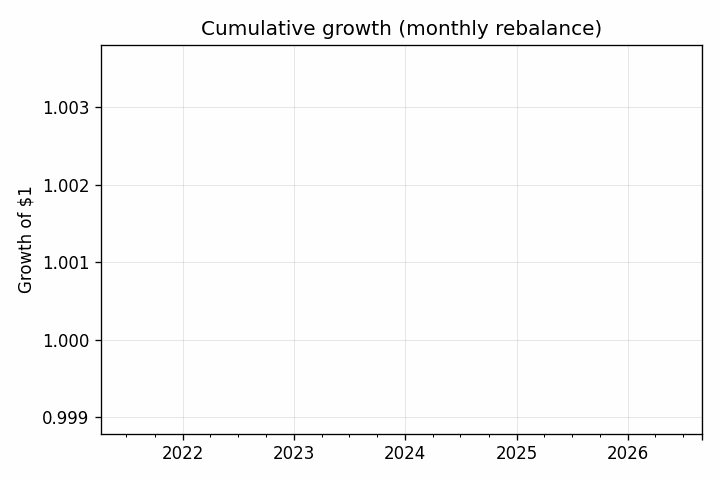

In [6]:
import os, sys

import matplotlib as mp
if "google.colab" not in sys.modules:
  mp.use("Agg")
else:
  %matplotlib notebook
  mp.use('module://matplotlib_inline.backend_inline')

import matplotlib.pyplot as plt
import imageio.v2 as imageio
from io import BytesIO
from IPython.display import Image, display

cum = (1 + port_rets).cumprod()

frame_idx = np.linspace(0, len(cum) - 1, 30).astype(int)

frames = []

for i, fi in enumerate(frame_idx):
    fig, ax = plt.subplots(figsize=(6, 4))
    cum.iloc[: fi + 1].plot(ax=ax, legend=False)
    ax.set_title("Cumulative growth (monthly rebalance)")
    ax.set_ylabel("Growth of $1")
    ax.grid(True, alpha=0.3)

    if fi == frame_idx[-1]:
        ax.legend(cum.columns, loc="upper left", fontsize=8)

    fig.tight_layout()

    # Render figure to in-memory buffer
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=120)
    plt.close(fig)
    buf.seek(0)

    frames.append(imageio.imread(buf))

# Create GIF in memory
gif_buf = BytesIO()
imageio.mimsave(gif_buf, frames, format="GIF", duration=0.2)
gif_buf.seek(0)

# Display inline in Jupyter
display(Image(data=gif_buf.read(), format="gif"))